# Disjoint 3 cell type partition sweep

evaluates FM and ODE trained in a hybrid AE latent space where the held out set is the union of 3 disjoint per cell type buckets (K562 A549 MCF7) at 30% holdout each every drug is held out for at most 1 cell type so each drug is seen perturbed in at least 2 cell types in train

sweeps geom reg distance loss weight in {0 1e-4 1e-2 1 1e2} across seeds {42 43 44} and shows downstream metrics per cell type with seed level error bars

experiment names follow `sciplex_{fm ode}_disjoint3_{wtag}_s{seed}` matching `scripts/train_disjoint3_ae_latent.sbatch` and `scripts/check_disjoint3_ae_latent.py`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite

WEIGHTS = [0.0, 1e-4, 1e-2, 1.0, 1e2]
SEEDS = [42, 43, 44]
MODELS = ["fm", "ode"]
CELL_TYPES = ["K562", "A549", "MCF7"]
RUNS_ROOT = Path("artifacts/runs")

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc"]
group_columns = ["cell_type", "product_dose"]
reductions = ["unweighted_mean"]

metric_lower_is_better = {"mean_gene_w1": True, "w2_squared": True, "cosine_log_fc": False}
metric_pretty = {
    "mean_gene_w1": r"mean gene $W_1$",
    "w2_squared": r"$W_2^2$",
    "cosine_log_fc": "cosine logFC",
}
metric_direction = {
    "mean_gene_w1": "\u2193",
    "w2_squared": "\u2193",
    "cosine_log_fc": "\u2191",
}
model_pretty = {"fm": "Flow Matching", "ode": "Neural ODE"}
model_colors = {"fm": "#4477AA", "ode": "#EE6677"}
theo_color = "#555555"


def _weight_tag(weight: float) -> str:
    if weight == 0:
        return "w0"
    return "w" + f"{weight:g}".replace(".", "p")


def _experiment_name(weight: float, seed: int, model: str) -> str:
    return f"sciplex_{model}_disjoint3_{_weight_tag(weight)}_s{seed}"

In [2]:
# discover available runs gracefully handles partial coverage so partial sweeps still plot
experiments = []
for model in MODELS:
    for weight in WEIGHTS:
        for seed in SEEDS:
            exp_name = _experiment_name(weight, seed, model)
            exp_dir = RUNS_ROOT / exp_name
            if not exp_dir.is_dir():
                continue
            subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
            if not subdirs:
                continue
            latest = subdirs[-1]
            if not (latest / "predictions" / "held_out" / "predictions.h5ad").exists():
                continue
            experiments.append({"weight": weight, "seed": seed, "model": model, "name": exp_name})

if not experiments:
    raise RuntimeError("no disjoint3 runs with predictions yet -- submit the sbatch first")

available_experiments = [e["name"] for e in experiments]

status = pd.DataFrame(experiments)
for model in MODELS:
    sub = status[status["model"] == model]
    if sub.empty:
        print(f"[{model}] no runs found")
        continue
    cov = sub.pivot_table(index="seed", columns="weight", values="name", aggfunc="count", fill_value=0)
    print(f"[{model}] coverage runs per (seed weight):")
    display(cov)

print(f"\n{len(experiments)} runs ready across {len(MODELS)} model types")

[fm] coverage runs per (seed weight):


weight,0.0000,0.0001,0.0100,1.0000,100.0000
seed,,,,,
42,1,1,1,1,1
43,1,1,1,1,1
44,1,1,1,1,1


[ode] coverage runs per (seed weight):


weight,0.0000,0.0001,0.0100,1.0000,100.0000
seed,,,,,
42,1,1,1,1,1
43,1,1,1,1,1
44,1,1,1,1,1



30 runs ready across 2 model types


In [3]:
# evaluate cached by prediction fingerprint so re-running this cell is a no op
# unless predictions changed on disk
import hashlib

CACHE_DIR = Path("artifacts/disjoint3_sweep_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _predictions_fingerprint(exp_names: list[str]) -> str:
    parts = []
    for exp in sorted(exp_names):
        exp_dir = RUNS_ROOT / exp
        subdirs = sorted(d for d in exp_dir.iterdir() if d.is_dir())
        if not subdirs:
            continue
        pred_path = subdirs[-1] / "predictions" / "held_out" / "predictions.h5ad"
        if pred_path.exists():
            parts.append(f"{pred_path}:{pred_path.stat().st_mtime}")
    return hashlib.sha256("|".join(parts).encode()).hexdigest()[:12]


cache_key = _predictions_fingerprint(available_experiments)
per_group_cache = CACHE_DIR / f"per_group_{cache_key}.parquet"

EVAL_BATCH_SIZE = 2

if per_group_cache.exists():
    per_group = pd.read_parquet(per_group_cache)
    print(f"loaded cached results ({cache_key})")
else:
    import gc

    pieces = []
    n_batches = (len(available_experiments) + EVAL_BATCH_SIZE - 1) // EVAL_BATCH_SIZE
    for bi in range(n_batches):
        batch = available_experiments[bi * EVAL_BATCH_SIZE : (bi + 1) * EVAL_BATCH_SIZE]
        print(f"  batch {bi + 1}/{n_batches}: {len(batch)} experiments")
        result = run_benchmark_suite(
            {
                "experiments": batch,
                "metrics": metrics,
                "group_columns": group_columns,
                "reductions": reductions,
            }
        )
        pieces.append(result["per_group_metrics"])
        del result
        gc.collect()
    per_group = pd.concat(pieces, ignore_index=True)
    per_group.to_parquet(per_group_cache)
    print(f"saved results to cache ({cache_key})")

name_to_meta = {e["name"]: (e["weight"], e["seed"], e["model"]) for e in experiments}
per_group["weight"] = per_group["model_name"].map(lambda n: name_to_meta.get(n, (np.nan,))[0])
per_group["seed"] = per_group["model_name"].map(lambda n: name_to_meta.get(n, (None, np.nan))[1])
per_group["model"] = per_group["model_name"].map(lambda n: name_to_meta.get(n, (None, None, None))[2])
print(f"per group rows: {len(per_group)}")
print("cell types in per_group:", sorted(per_group["cell_type"].dropna().unique().tolist()))
display(per_group.head())

loaded cached results (34cf394e1f02)
per group rows: 60450
cell types in per_group: ['A549', 'K562', 'MCF7']


,model_name,cell_type,product_dose,n_pred,n_ref,n_ctrl,aggregation,metric,metric_base,category,value,prediction_name,metric_space,metric_space_label,weight,seed,model
0,sciplex_fm_disjoint3_w0_s42,A549,AG-14361_10,36,36,7349,none,mean_gene_w1,mean_gene_w1,cell_distribution,0.302529,held_out,comparison,normalized_log1p,0.0,42,fm
1,sciplex_fm_disjoint3_w0_s42,A549,AG-14361_10,36,36,7349,none,w2_squared,w2_squared,cell_distribution,2142.381435,held_out,comparison,normalized_log1p,0.0,42,fm
2,sciplex_fm_disjoint3_w0_s42,A549,AG-14361_10,36,36,7349,logfc,cosine_log_fc,cosine_log_fc,profile,0.003573,held_out,comparison,normalized_log1p,0.0,42,fm
3,sciplex_fm_disjoint3_w0_s42,A549,AG-14361_100,38,38,7349,none,mean_gene_w1,mean_gene_w1,cell_distribution,0.309012,held_out,comparison,normalized_log1p,0.0,42,fm
4,sciplex_fm_disjoint3_w0_s42,A549,AG-14361_100,38,38,7349,none,w2_squared,w2_squared,cell_distribution,2119.085539,held_out,comparison,normalized_log1p,0.0,42,fm


In [4]:
# 2-level aggregation
# per (weight seed model cell_type metric) -> mean across (product dose)
# then across seeds -> mean and std with seed-level error bars
metric_col = "metric_base" if "metric_base" in per_group.columns else "metric"
value_col = "value" if "value" in per_group.columns else "metric_value"

per_run = (
    per_group[per_group[metric_col].isin(metrics)]
    .groupby(["model", "weight", "seed", "cell_type", metric_col], as_index=False)[value_col]
    .mean()
    .rename(columns={metric_col: "metric", value_col: "value"})
)

agg = (
    per_run.groupby(["model", "weight", "cell_type", "metric"], as_index=False)["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg["sem"] = agg["std"] / np.sqrt(agg["count"].clip(lower=1))

print("per-run rows (one per (weight seed model cell_type metric)):", len(per_run))
print("aggregate rows (one per (weight model cell_type metric)):", len(agg))
display(agg.head(12))

per-run rows (one per (weight seed model cell_type metric)): 270
aggregate rows (one per (weight model cell_type metric)): 90


,index,model,weight,cell_type,metric,mean,std,count,sem
0,0,fm,0.0000,A549,cosine_log_fc,0.037383,0.004575,3,0.002641
1,1,fm,0.0000,A549,mean_gene_w1,0.308776,0.001235,3,0.000713
2,2,fm,0.0000,A549,w2_squared,2186.366838,6.648069,3,3.838264
3,3,fm,0.0000,K562,cosine_log_fc,0.050286,0.003238,3,0.001869
4,4,fm,0.0000,K562,mean_gene_w1,0.319003,0.005876,3,0.003393
5,5,fm,0.0000,K562,w2_squared,2384.311792,4.337337,3,2.504163
6,6,fm,0.0000,MCF7,cosine_log_fc,0.029193,0.017434,3,0.010066
7,7,fm,0.0000,MCF7,mean_gene_w1,0.303084,0.003114,3,0.001798
8,8,fm,0.0000,MCF7,w2_squared,1926.882449,15.522463,3,8.961898
9,9,fm,0.0001,A549,cosine_log_fc,0.192739,0.009909,3,0.005721


/tmp/ipykernel_163936/2206640209.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.06, 1, 0.95), w_pad=0.5)


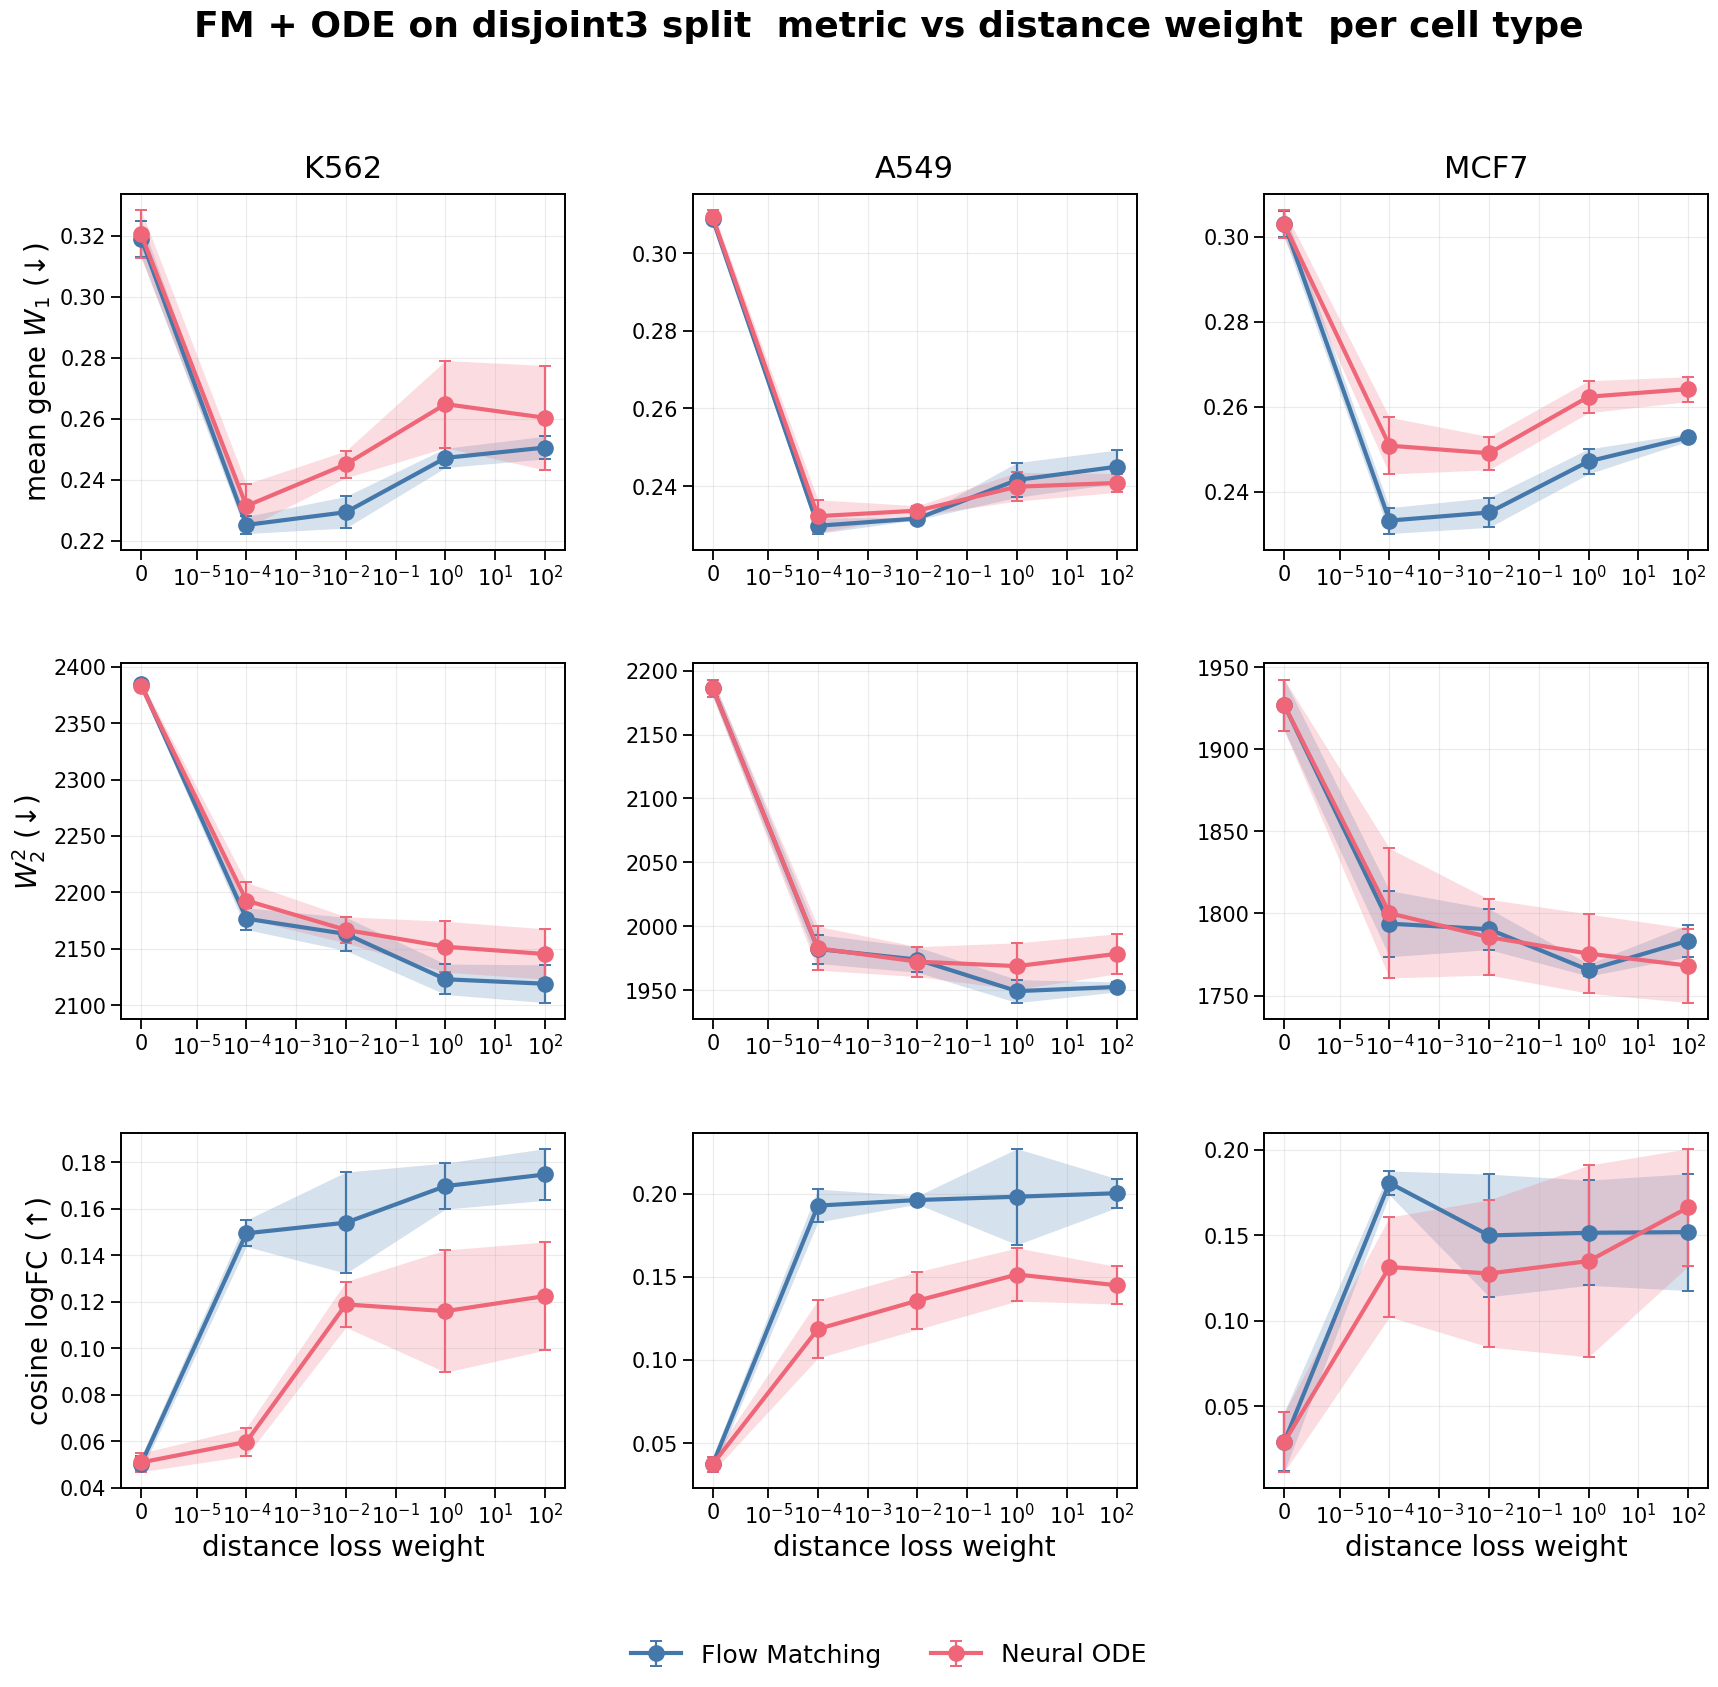

In [5]:
# per cell type figure  rows = metrics  cols = cell types  poster styled
# style copied from view_geom_reg_sweep.ipynb so the visual identity stays
# consistent across the thesis sweeps
n_metrics = len(metrics)
n_cells = len(CELL_TYPES)

with plt.rc_context(
    {
        "font.size": 18,
        "axes.titlesize": 22,
        "axes.labelsize": 20,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 18,
        "axes.linewidth": 1.6,
        "lines.linewidth": 3.0,
        "lines.markersize": 11,
    }
):
    fig, axes = plt.subplots(
        n_metrics,
        n_cells,
        figsize=(7.0 * n_cells, 5.6 * n_metrics),
        gridspec_kw={"wspace": 0.18, "hspace": 0.32},
        squeeze=False,
    )

    for r, metric in enumerate(metrics):
        for c, cell_type in enumerate(CELL_TYPES):
            ax = axes[r][c]
            for model in MODELS:
                sub = agg[
                    (agg["model"] == model) & (agg["cell_type"] == cell_type) & (agg["metric"] == metric)
                ].sort_values("weight")
                if sub.empty:
                    continue
                color = model_colors.get(model)
                xs = sub["weight"].to_numpy()
                ys = sub["mean"].to_numpy()
                yerr = sub["std"].fillna(0).to_numpy()
                ax.errorbar(
                    xs,
                    ys,
                    yerr=yerr,
                    marker="o",
                    color=color,
                    label=model_pretty.get(model, model.upper()),
                    capsize=4,
                    capthick=1.4,
                    elinewidth=1.6,
                    zorder=3,
                )
                if len(xs) > 1:
                    ax.fill_between(xs, ys - yerr, ys + yerr, alpha=0.22, color=color, linewidth=0)

            ax.set_xscale("symlog", linthresh=1e-5)
            ax.grid(alpha=0.25, linewidth=0.8)
            ax.tick_params(axis="both", which="major", length=7, width=1.3)
            for spine in ax.spines.values():
                spine.set_linewidth(1.4)
            ax.set_box_aspect(4 / 5)
            if r == 0:
                ax.set_title(cell_type, pad=12)
            if r == n_metrics - 1:
                ax.set_xlabel("distance loss weight")
            if c == 0:
                pretty = metric_pretty.get(metric, metric)
                direction = metric_direction.get(metric, "")
                ax.set_ylabel(f"{pretty} ({direction})")

    fig.tight_layout(rect=(0, 0.06, 1, 0.95), w_pad=0.5)

    seen = set()
    handles_all, labels_all = [], []
    for ax_row in axes:
        for ax in ax_row:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in seen:
                    seen.add(l)
                    handles_all.append(h)
                    labels_all.append(l)
    if handles_all:
        fig.legend(
            handles_all,
            labels_all,
            loc="lower center",
            ncol=len(labels_all),
            bbox_to_anchor=(0.5, -0.01),
            frameon=False,
        )

    fig.suptitle(
        "FM + ODE on disjoint3 split  metric vs distance weight  per cell type",
        fontsize=26,
        fontweight="bold",
        y=0.99,
    )
    plt.show()
    Path("figures").mkdir(exist_ok=True)
    fig.savefig("figures/disjoint3_sweep_per_cell_type.pdf", bbox_inches="tight")

/tmp/ipykernel_163936/766525783.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.18, 1, 0.93), w_pad=0.5)


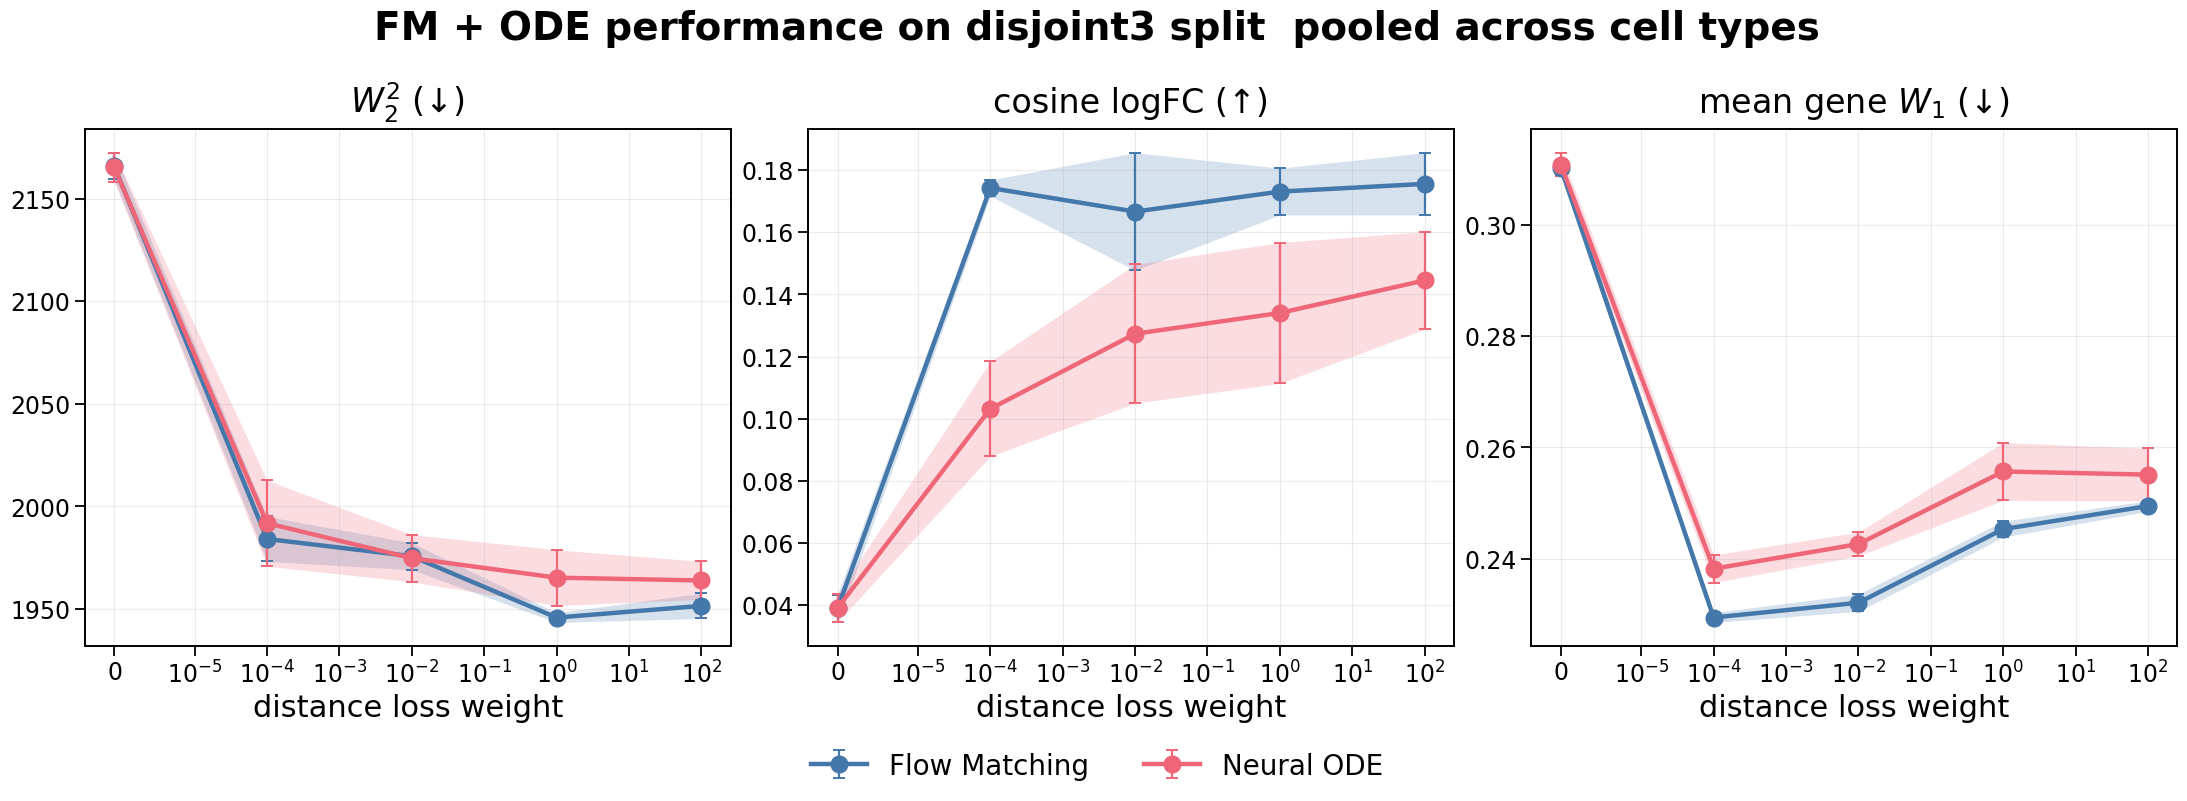

,index,model,weight,metric,mean,std,count
0,0,fm,0.0000,cosine_log_fc,0.038954,0.004489,3
1,1,fm,0.0000,mean_gene_w1,0.310287,0.001391,3
2,2,fm,0.0000,w2_squared,2165.853693,6.471165,3
3,3,fm,0.0001,cosine_log_fc,0.174202,0.002566,3
4,4,fm,0.0001,mean_gene_w1,0.229382,0.000885,3
5,5,fm,0.0001,w2_squared,1984.179350,10.951286,3
6,6,fm,0.0100,cosine_log_fc,0.166604,0.018935,3
7,7,fm,0.0100,mean_gene_w1,0.232038,0.001549,3
8,8,fm,0.0100,w2_squared,1975.760152,6.542409,3
9,9,fm,1.0000,cosine_log_fc,0.173042,0.007525,3


In [6]:
# pooled across cell types poster styled near direct copy of geom reg sweep poster figure
pooled = (
    per_run.groupby(["model", "weight", "seed", "metric"], as_index=False)["value"]
    .mean()
    .groupby(["model", "weight", "metric"], as_index=False)["value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

POSTER_METRICS = ["w2_squared", "cosine_log_fc", "mean_gene_w1"]
plot_metrics = [m for m in POSTER_METRICS if m in pooled["metric"].unique()]
n_metrics_p = len(plot_metrics)

with plt.rc_context(
    {
        "font.size": 18,
        "axes.titlesize": 24,
        "axes.labelsize": 22,
        "xtick.labelsize": 17,
        "ytick.labelsize": 17,
        "legend.fontsize": 20,
        "axes.linewidth": 1.6,
        "lines.linewidth": 3.2,
        "lines.markersize": 12,
    }
):
    fig, axes = plt.subplots(
        1,
        n_metrics_p,
        figsize=(9.0 * n_metrics_p, 7.8),
        gridspec_kw={"wspace": 0.12},
    )
    axes = np.atleast_1d(axes)

    for ax_idx, metric in enumerate(plot_metrics):
        ax = axes[ax_idx]

        for model in MODELS:
            mdf = pooled[(pooled["metric"] == metric) & (pooled["model"] == model)].sort_values("weight")
            if mdf.empty:
                continue
            color = model_colors.get(model)
            weights = mdf["weight"].to_numpy()
            mean_arr = mdf["mean"].to_numpy()
            std_arr = mdf["std"].fillna(0).to_numpy()
            ax.errorbar(
                weights,
                mean_arr,
                yerr=std_arr,
                marker="o",
                color=color,
                label=model_pretty.get(model, model.upper()),
                capsize=4,
                capthick=1.4,
                elinewidth=1.6,
                zorder=3,
            )
            if len(weights) > 1:
                ax.fill_between(
                    weights,
                    mean_arr - std_arr,
                    mean_arr + std_arr,
                    alpha=0.22,
                    color=color,
                    linewidth=0,
                )

        direction = metric_direction.get(metric, "")
        pretty = metric_pretty.get(metric, metric)
        ax.set_xlabel("distance loss weight")
        ax.set_title(f"{pretty} ({direction})", pad=12)
        ax.set_xscale("symlog", linthresh=1e-5)
        ax.grid(alpha=0.25, linewidth=0.8)
        ax.tick_params(axis="both", which="major", length=7, width=1.3)
        for spine in ax.spines.values():
            spine.set_linewidth(1.4)
        ax.set_box_aspect(4 / 5)

    fig.tight_layout(rect=(0, 0.18, 1, 0.93), w_pad=0.5)

    seen = set()
    handles_all, labels_all = [], []
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen:
                seen.add(l)
                handles_all.append(h)
                labels_all.append(l)
    fig.legend(
        handles_all,
        labels_all,
        loc="lower center",
        ncol=len(labels_all),
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
    )

    fig.suptitle(
        "FM + ODE performance on disjoint3 split  pooled across cell types",
        fontsize=28,
        fontweight="bold",
        y=0.98,
    )
    plt.show()
    Path("figures").mkdir(exist_ok=True)
    fig.savefig("figures/disjoint3_sweep_pooled_poster.svg", bbox_inches="tight")

display(pooled)

In [7]:
# summary table best (weight model) per (cell_type metric) using seed-mean direction-aware
rows = []
for cell_type in CELL_TYPES:
    for metric in metrics:
        sub = agg[(agg["cell_type"] == cell_type) & (agg["metric"] == metric)].copy()
        if sub.empty:
            continue
        ascending = metric_lower_is_better.get(metric, True)
        best_idx = sub["mean"].idxmin() if ascending else sub["mean"].idxmax()
        best = sub.loc[best_idx]
        rows.append(
            {
                "cell_type": cell_type,
                "metric": metric,
                "best_model": best["model"],
                "best_weight": best["weight"],
                "best_mean": best["mean"],
                "best_std": best["std"],
                "n_seeds": int(best["count"]),
            }
        )
summary = pd.DataFrame(rows)
print("best (weight model) per (cell_type metric) seed-mean direction-aware")
display(summary)

best (weight model) per (cell_type metric) seed-mean direction-aware


,cell_type,metric,best_model,best_weight,best_mean,best_std,n_seeds
0,K562,mean_gene_w1,fm,0.0001,0.225219,0.002810,3
1,K562,w2_squared,fm,100.0000,2118.958369,16.752337,3
2,K562,cosine_log_fc,fm,100.0000,0.174631,0.011104,3
3,A549,mean_gene_w1,fm,0.0001,0.229754,0.001998,3
4,A549,w2_squared,fm,1.0000,1949.147086,8.998970,3
5,A549,cosine_log_fc,fm,100.0000,0.200179,0.008702,3
6,MCF7,mean_gene_w1,fm,0.0001,0.233173,0.003049,3
7,MCF7,w2_squared,fm,1.0000,1765.540300,3.718993,3
8,MCF7,cosine_log_fc,fm,0.0001,0.180521,0.007028,3
